# NFHS-5 Lifestyle Theme Analysis

## Overview

The National Family Health Survey (NFHS-5) provides district-level indicators on health, nutrition, and lifestyle across India. In this notebook, we focus on lifestyle-related indicators, particularly tobacco and alcohol consumption among men aged 15 years and above.

## Objectives

* Examine the distribution of tobacco and alcohol consumption across districts.
* Identify states and districts with the highest and lowest prevalence.
* Compare district-level and state-level patterns.
* Explore the relationship between tobacco use, alcohol consumption, and selected health indicators.

## Dataset

* Source: NFHS-5 (2019–21)
* Level of Analysis: District
* Theme: Lifestyle and Health Indicators



In [1]:
import pandas as pd 
import numpy as np 
df_clean=pd.read_csv("nfhs5_cleaned_final.csv")
df_clean.shape

(704, 106)

In [2]:
[col for col in df_clean.columns if col.lower().startswith("men_")]

['men_age_group_15_years_and_above_who_consume_alcohol',
 'men_age_group_15_years_and_above_who_use_any_kind_of_tobacco',
 'men_suffering_from_high_blood_sugar_level',
 'men_suffering_from_high_or_very_high_blood_sugar_level',
 'men_suffering_from_very_high_blood_sugar_level',
 'men_mildly_elevated_blood_pressure']

In [3]:
men_cols=['men_age_group_15_years_and_above_who_consume_alcohol',
 'men_age_group_15_years_and_above_who_use_any_kind_of_tobacco',
 'men_suffering_from_high_blood_sugar_level',
 'men_suffering_from_high_or_very_high_blood_sugar_level',
 'men_suffering_from_very_high_blood_sugar_level',
 'men_mildly_elevated_blood_pressure']


## Descriptive Stats

In [4]:
df_clean[men_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
men_age_group_15_years_and_above_who_consume_alcohol,704.0,23.265767,13.404655,0.1,13.60,20.45,31.000,68.4
men_age_group_15_years_and_above_who_use_any_kind_of_tobacco,704.0,40.635227,14.098882,6.8,30.45,42.50,50.925,80.6
men_suffering_from_high_blood_sugar_level,704.0,6.996733,2.116246,1.7,5.40,6.70,8.300,18.3
men_suffering_from_high_or_very_high_blood_sugar_level,704.0,14.709517,4.956139,4.8,11.10,14.10,17.600,36.2
men_suffering_from_very_high_blood_sugar_level,704.0,6.638210,3.122101,0.5,4.40,6.30,8.300,21.1
men_mildly_elevated_blood_pressure,704.0,16.258097,4.345131,5.3,13.20,16.25,18.900,32.9


## Tobacco Consumption Analysis

In [5]:
df_clean["men_age_group_15_years_and_above_who_use_any_kind_of_tobacco"].describe()

count    704.000000
mean      40.635227
std       14.098882
min        6.800000
25%       30.450000
50%       42.500000
75%       50.925000
max       80.600000
Name: men_age_group_15_years_and_above_who_use_any_kind_of_tobacco, dtype: float64

## Top 10 States by Tobacco prevalence

In [6]:
df_clean.groupby("state")["men_age_group_15_years_and_above_who_use_any_kind_of_tobacco"].mean().sort_values(ascending=False).head(10)

state
Mizoram                        74.900000
Andaman And Nicobar Islands    66.033333
Manipur                        60.888889
Meghalaya                      59.272727
Tripura                        57.825000
Assam                          52.948485
Odisha                         51.313333
Arunachal Pradesh              49.375000
Nagaland                       49.063636
Bihar                          48.850000
Name: men_age_group_15_years_and_above_who_use_any_kind_of_tobacco, dtype: float64

## Bottom 10  states by Tobacco prevalence

In [7]:
df_clean.groupby("state")[
    "men_age_group_15_years_and_above_who_use_any_kind_of_tobacco"
].mean().sort_values().head(10)

state
Punjab            13.350000
Puducherry        14.100000
Goa               18.050000
Kerala            18.050000
Tamil Nadu        20.821875
Andhra Pradesh    22.415385
Telangana         24.178125
Delhi             26.345455
Karnataka         27.723333
Haryana           29.100000
Name: men_age_group_15_years_and_above_who_use_any_kind_of_tobacco, dtype: float64

## A large interstate variation in tobacco use was observed. Mizoram had the highest prevalence (74.9%), whereas Punjab had the lowest (13.35%). Several North-Eastern states appeared among the highest-prevalence region

## Top 10  districts by Tobacco Prevalence

In [8]:
## district level 
df_clean.groupby("district")["men_age_group_15_years_and_above_who_use_any_kind_of_tobacco"].mean().sort_values(ascending=False).head(10)


district
Mamit               80.6
Lawngtlai           77.2
Nicobars            76.8
Kolasib             75.3
Lunglei             75.0
Champhai            74.5
Serchhip            74.2
Churachandpur       73.8
Siaha               73.7
West Khasi Hills    73.3
Name: men_age_group_15_years_and_above_who_use_any_kind_of_tobacco, dtype: float64

## Bottom 10  districts by Tobacco Prevalence

In [9]:
df_clean.groupby("district")[
    "men_age_group_15_years_and_above_who_use_any_kind_of_tobacco"
].mean().sort_values().head(10)

district
Tarn Taran                    6.8
Gurdaspur                     7.9
Amritsar                      8.2
Chennai                       8.9
Hoshiarpur                   10.1
Yanam                        10.3
Shahid Bhagat Singh Nagar    10.9
Kanniyakumari                11.0
Patiala                      11.2
Jalandhar                    11.3
Name: men_age_group_15_years_and_above_who_use_any_kind_of_tobacco, dtype: float64

## The district-level results support the state-level findings, with several districts from Mizoram appearing among the highest-prevalence regions and districts from Punjab among the lowest. This suggests that the observed regional differences in tobacco consumption are consistent across both state and district levels.

## Histogram of the Tobacco column

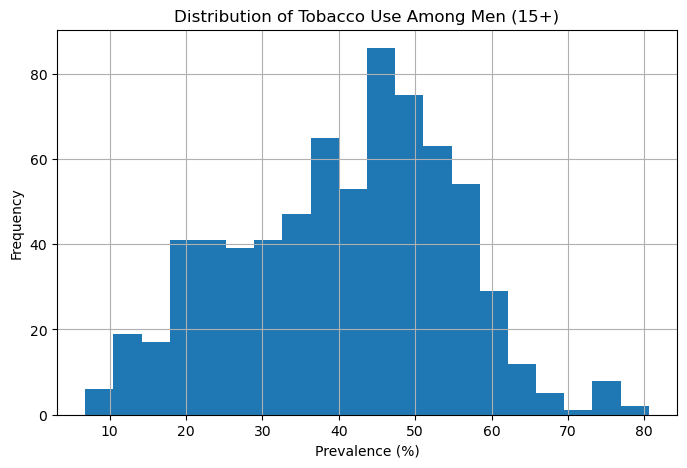

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df_clean["men_age_group_15_years_and_above_who_use_any_kind_of_tobacco"].hist(
    bins=20
)

plt.title("Distribution of Tobacco Use Among Men (15+)")
plt.xlabel("Prevalence (%)")
plt.ylabel("Frequency")
plt.show()

## Most districts report tobacco prevalence between 20% and 60%, with the highest concentration around 40%–50%. Extremely high and low prevalence values are relatively uncommon.

## Mizoram vs Overall 

In [11]:
print("Mizoram vs overall" , 74.9/40)

Mizoram vs overall 1.8725


# Mizoram reported the highest average tobacco prevalence (74.9%), which is approximately 1.87 times the overall district-level average, highlighting the state's exceptionally high tobacco consumption relative to the rest of the country

## Alcohol Consumption Analysis

In [12]:
df_clean['men_age_group_15_years_and_above_who_consume_alcohol'].describe()

count    704.000000
mean      23.265767
std       13.404655
min        0.100000
25%       13.600000
50%       20.450000
75%       31.000000
max       68.400000
Name: men_age_group_15_years_and_above_who_consume_alcohol, dtype: float64

## Distribution of Alcohol

<Axes: >

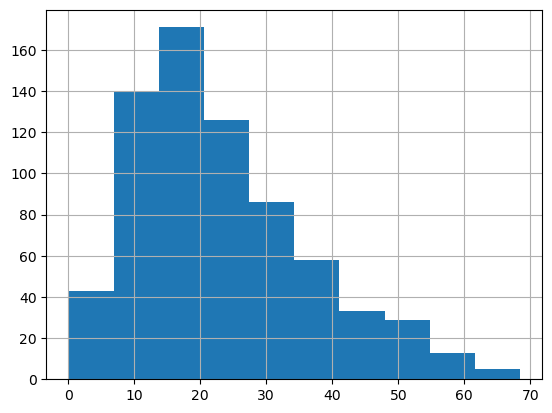

In [13]:
df_clean['men_age_group_15_years_and_above_who_consume_alcohol'].hist()

## Alcohol consumption among men shows notable variation across districts, with an average prevalence of 23%. Values range from 0.1% to 68%, and the relatively high standard deviation (13%) indicates substantial differences in alcohol consumption across regions.

## Top 10 States by Alcohol prevalence

In [14]:
df_clean.groupby("state")["men_age_group_15_years_and_above_who_consume_alcohol"].mean().sort_values(ascending=False).head(10)


state
Arunachal Pradesh              53.035000
Andaman And Nicobar Islands    47.533333
Telangana                      45.753125
Sikkim                         42.100000
Chhattisgarh                   37.859259
Goa                            37.450000
Jharkhand                      37.391667
Manipur                        37.377778
Meghalaya                      34.490909
Himachal Pradesh               33.758333
Name: men_age_group_15_years_and_above_who_consume_alcohol, dtype: float64

## Top 10 Districts

In [15]:
df_clean.groupby("district")[ 
    "men_age_group_15_years_and_above_who_consume_alcohol"
].mean().sort_values(ascending=False).head(10)

district
Anjaw              68.4
Upper Subansiri    65.6
Nicobars           64.5
Dibang Valley      64.3
Namsai             61.6
Upper Siang        61.2
Changlang          60.9
Bijapur            60.8
Siang              60.6
Jangoan            60.6
Name: men_age_group_15_years_and_above_who_consume_alcohol, dtype: float64

## Arunachal Pradesh recorded the highest alcohol prevalence among states. Several of the highest-prevalence districts also belonged to Arunachal Pradesh, indicating a consistent pattern at both the state and district levels.


 ## Tobacco vs Alcohol Consumption

 ## After analyzing tobacco and alcohol separately, we now examine whether districts with higher tobacco use also tend to have higher alcohol consumption. This helps us understand if the two lifestyle factors are related across districts.



## Scatter Plot of Tobacco Vs Alcohol

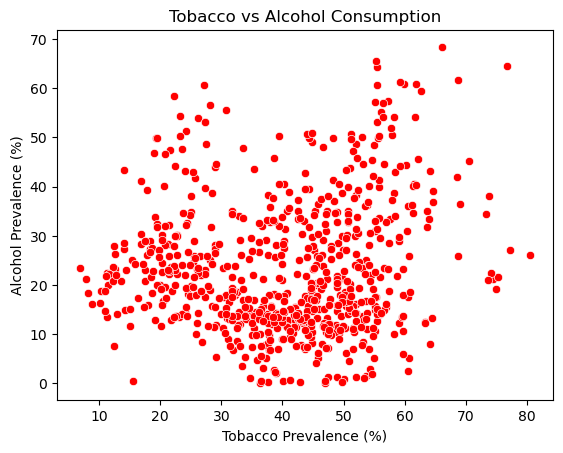

0.10266351667183272

In [17]:
import seaborn as sns
sns.scatterplot(
    data=df_clean,
    x="men_age_group_15_years_and_above_who_use_any_kind_of_tobacco",
    y="men_age_group_15_years_and_above_who_consume_alcohol" , color="red"
)

plt.xlabel("Tobacco Prevalence (%)")
plt.ylabel("Alcohol Prevalence (%)")
plt.title("Tobacco vs Alcohol Consumption")
plt.show()

## correlation coefficient 
tobacco_col = "men_age_group_15_years_and_above_who_use_any_kind_of_tobacco"
alcohol_col = "men_age_group_15_years_and_above_who_consume_alcohol"

df_clean[[tobacco_col, alcohol_col]].corr()
df_clean[tobacco_col].corr(df_clean[alcohol_col])

## The scatter plot does not show a clear relationship between tobacco and alcohol prevalence across districts. The Pearson correlation coefficient (r = 0.103) indicates a very weak positive association, suggesting that districts with higher tobacco use do not necessarily report higher alcohol consumption.


## Heat Map

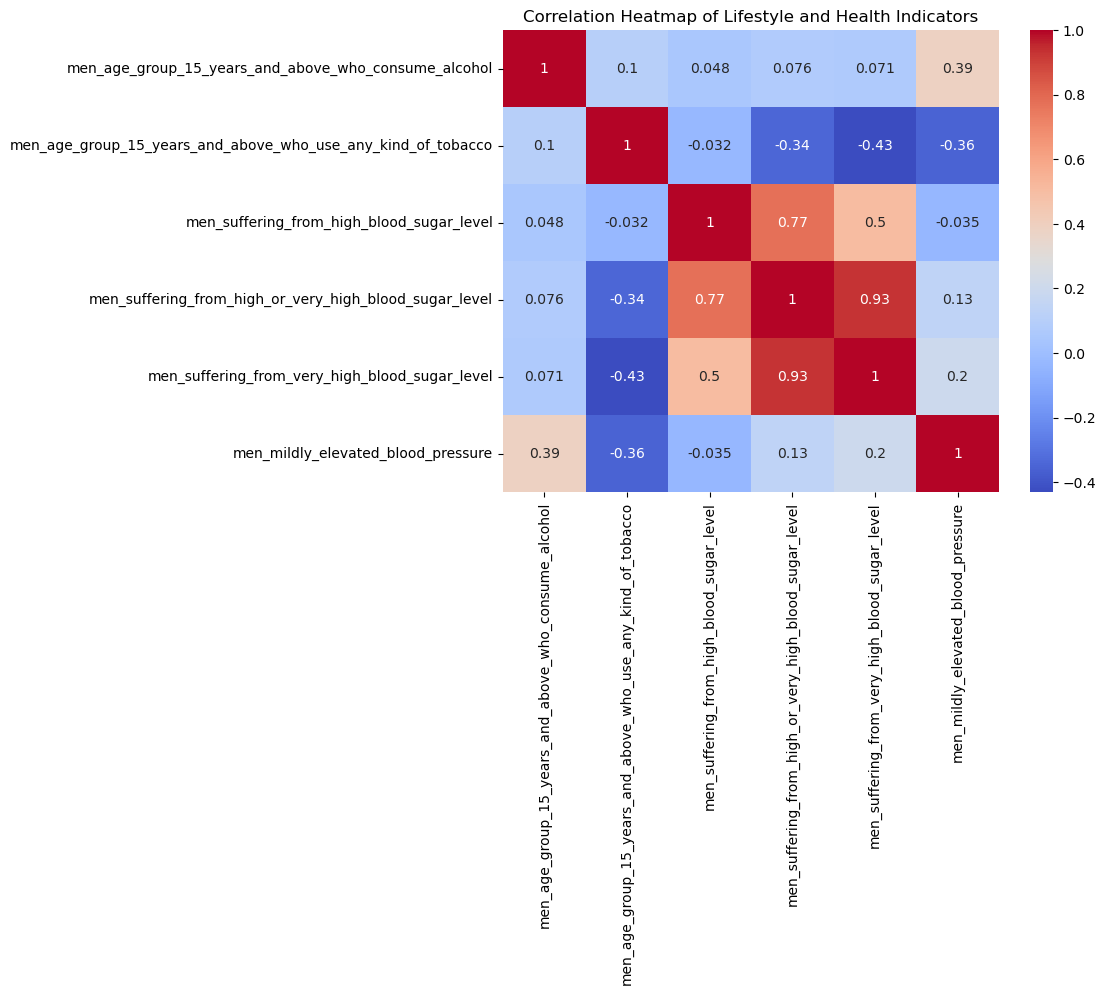

In [18]:
corr_matrix = df_clean[men_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Lifestyle and Health Indicators")
plt.show()

## The heatmap shows that tobacco and alcohol consumption follow different patterns across districts and do not appear to be closely related. 
## Alcohol consumption shows some association with mildly elevated blood pressure, while the blood sugar indicators display similar patterns since they represent related health conditions.


## Final Conclusions

* Tobacco and alcohol consumption vary considerably across districts in India.
* Several North-Eastern states consistently reported higher tobacco and alcohol consumption than many other regions.
* The district-level analysis supported the state-level findings, with many high-prevalence districts belonging to the same high-prevalence states.
* Most districts showed moderate levels of tobacco and alcohol consumption, while extremely high and low values were observed in only a small number of districts.
* Tobacco and alcohol consumption did not appear to be strongly related across districts, suggesting that the two indicators follow different patterns.
